In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd
from qiskit import transpile
from qiskit.circuit.library import  UnitaryGate
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [3]:
SEED = 1234
backend = AerSimulator(seed_simulator=SEED)
sampler = Sampler(backend)

# The problem

> ### Shor's factoring problem
> **Input:**  
> * A composite integer $N$.
>
> **Output:**  
> * A non-trivial factor of $N$.


Although the factoring problem may look simple to state, it is extremely important in modern cryptography. Many widely used public-key cryptosystems rely on mathematical problems that are easy to compute in one direction but hard to reverse, such as factoring the product of two large primes in RSA or solving discrete logarithms in elliptic-curve cryptography. Shor's algorithm is relevant because a sufficiently powerful quantum computer could solve these problems efficiently, which would compromise much of today's public-key cryptography.

# The algorithm

The quantum part of Shor's algorithm reduces the problem to finding the period, or order, $r$ of the function:

$$
f(x) = a^x \bmod N
$$

where $a$ is an integer such that:

$$
1 < a < N
$$

and:

$$
\gcd(a, N) = 1
$$

The period $r$ is the smallest positive integer satisfying:

$$
a^r \equiv 1 \pmod{N}
$$

Once $r$ is found, we can try to recover non-trivial factors of $N$ using:

$$
\gcd(a^{r/2} \pm 1, N)
$$


If these values give non-trivial factors, then the factorization of $N$ has been found. However, this does not always happen. If $r$ is odd, or if the algorithm returns only trivial factors such as $1$ or $N$, we can simply choose another valid value of $a$ and repeat the process until non-trivial factors are obtained.  

Shor's algorithm is also a good example of a hybrid quantum-classical algorithm. The quantum computer is only used for the part that is hard classically: finding the period $r$ of the modular function. The remaining steps, such as choosing a valid value of $a$, computing greatest common divisors, checking whether the factors are trivial, and repeating the process if needed, are performed on a classical computer.

Classically, the best-known general-purpose method for solving the factorization problem is the General Number Field Sieve (GNFS), with sub-exponential time complexity:

$$
\exp\left(O\left((\log N)^{1/3}(\log \log N)^{2/3}\right)\right)
$$

In comparison, Shor's algorithm can solve the same problem in polynomial time, usually expressed as approximately:

$$
O((\log N)^3)
$$

This exponential improvement is what makes Shor's algorithm especially relevant for cryptography. 

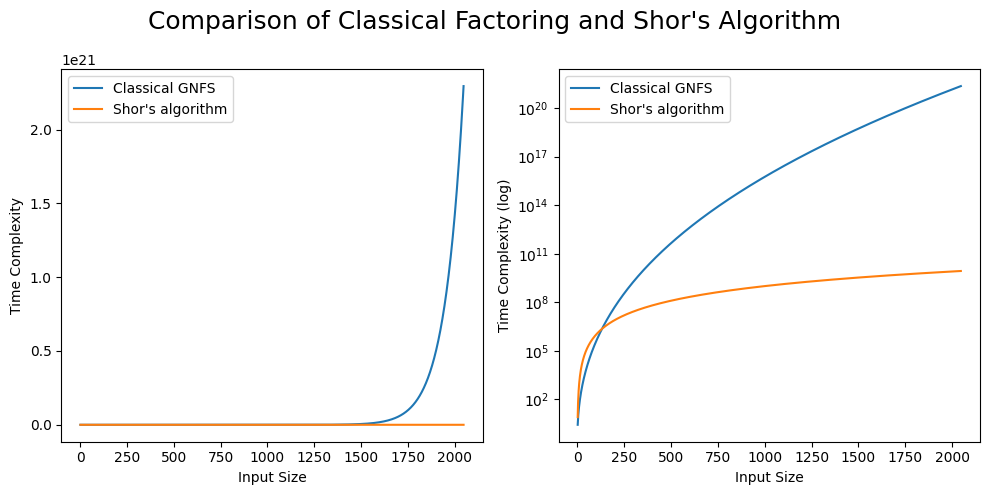

In [4]:
input_size = [i for i in range(2, 2048)]

gnfs = [np.exp((i**(1/3)) * (np.log(i)**(2/3))) for i in input_size]
shor = [i**3 for i in input_size]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(input_size, gnfs, label='Classical GNFS')
ax1.plot(input_size, shor, label="Shor's algorithm")
ax1.set_xlabel('Input Size')
ax1.set_ylabel('Time Complexity')
ax1.legend()

ax2.plot(input_size, gnfs, label='Classical GNFS')
ax2.plot(input_size, shor, label="Shor's algorithm")
ax2.set_xlabel('Input Size')
ax2.set_ylabel('Time Complexity (log)')
ax2.set_yscale("log")
ax2.legend()

fig.suptitle("Comparison of Classical Factoring and Shor's Algorithm", fontsize=18)
plt.tight_layout()
plt.show()

# Circuit implementation of the algorithm

Let's first explain the whole algorithm to help estimate $r$. We start with a counting register of size $m$ in the state $|0\rangle$ and a target register of size $n$ in the state $|1\rangle$ where $n$ is the size of $N$ in binary. The state $|1\rangle$ is represented in binary, so, for example if we have $n=3$, then $|1\rangle=|001\rangle$. We usually take $m=2n$. 

First, we apply Hadamard gates to the counting register. This transforms the initial state

$$
|0\rangle|1\rangle
$$


into a uniform superposition:

$$
\frac{1}{\sqrt{2^m}}\sum_{j=0}^{2^m-1}|j\rangle|1\rangle
$$

Next, we apply controlled powers of the unitary operator to the counting register:

$$
CU_a^{2^0},\ CU_a^{2^1},\ CU_a^{2^2},\ \ldots,\ CU_a^{2^{m-1}}
$$

where $U_a^{2l}$ represents the $2l$-th power of the modular exponentiation operator and performs the transformation:

$$
U_a^{2l}\,|y\rangle = |y \cdot a^{2l} \bmod N\rangle
$$

After the controlled-unitary operations, the global state becomes:

$$
\frac{1}{\sqrt{2^m}}\sum_{j=0}^{2^m-1}|j\rangle|a^j\bmod N\rangle
$$

Because $a^j \bmod N$ is periodic with period $r$ ($a^{j+r} mod N = a^j mod N$), the first register is now in a periodic superposition:

$$
|j_0\rangle + |j_0 + r\rangle + |j_0 + 2r\rangle + \ldots
$$

To obtain information about the periodicity of the state, we apply the inverse Quantum Fourier transform tp the couting register:

$$
QFT_N^\dagger = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} \sum_{y=0}^{N-1} \omega_N^{-xy} |y\rangle \langle x|
$$

where:

$$
\omega_N = e^{2\pi i/N}
$$


The phase information previously stored in the amplitudes of the counting register gets converted into a measurable binary number $l$. Analogous to a classical Fourier transform, peaks appear at multiples of $2^m / r$ corresponding to the period $r$, so with high probability, measuring the counting register yields $l$ such that:

$$
\frac{l}{2^m} \approx \frac{k}{r}
$$

So, if we measure several times, we will obtain several values that, with high probability, will be close to:

$$
\frac{k_12^m}{r}, \frac{k_22^m}{r}, \ldots,\frac{k_t2^m}{r}
$$

for some integers $k_1, k_2, \ldots, k_t$, from which we can recover $r$ using some classical post-processing. As we said previously, the only task of the quantum computer in Shor's algorithm is to help to find $r$, and once we have it, we use a classical computer to obtain the factors of $N$.

We almost have all the pieces to build the circuit. We just need to find out how to implement $U_a$ using quantum gates. For that, we will follow a very straightforward approach: we will build a unitary matrix $M$ that performs the desired transformation and turn it into a gate using the `UnitaryGate` class from `qiskit.circuit.library`. In order to build $M$, we just need to interpret the states as binary (i.e $|101\rangle=|2^2+2^0\rangle=|5\rangle$) and insert the modular multiplication operation into a matrix. For example if $N=4$ and $a=3$:

$$
3\cdot 0=0 \bmod 4,\quad 3\cdot 1=3 \bmod 4,\quad 3\cdot 2=2 \bmod 4,\quad 3\cdot 3=1 \bmod 4
$$

then:

$$
U_a|00\rangle = |00\rangle,\quad U_a|01\rangle = |11\rangle,\quad U_a|10\rangle = |10\rangle,\quad U_a|11\rangle = |01\rangle
$$

So the matrix $U_{a=3}$ is:

$$
\begin{pmatrix} 1 & 0 & 0 & 0\\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \\  0 & 1 & 0 & 0\end{pmatrix}
$$

It's very important to take into account Qiskit ordering convention while building the matrix. For that reason, the matrix we would actually implement is:

$$
\begin{pmatrix} 1 & 0 & 0 & 0\\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\  0 & 0 & 1 & 0\end{pmatrix}
$$

Let's now create a function to create this unitaries for any given value of $a$ and $N$, and, finally, build and execute Shor's algorithm.

In [5]:
def invert_int(i: int, n: int) -> int:
    """
    Inverts the integer i when represented with n bits.
    """
    # Convert to binary and get rid of the "0b" at the start
    i_bin = bin(i)[2:]
    # Pad with zeros to use n bits
    i_bin_padded = (n-len(i_bin)) * "0" + i_bin 
    # Reverse
    i_bin_inverted = i_bin_padded[::-1] 
    
    return int(i_bin_inverted, 2) # Return the reversed integer


def build_shor_unitary(N: int, a: int) -> UnitaryGate:
    """
    Builds a Qiskit unitary U gate that performs the operation U|y> = |a y modN> for a given 'N' and 'a'.
    """
    n = len(bin(N-1)) - 2 # Number of qubits needed to store M

    # Initialize empty matrix
    size_M = 2**n
    M = np.zeros((size_M, size_M), dtype="complex")

    for col in range(N):
        # Perform the modular multiplication operation and get the row that we need to set to 1
        row = (a * col) % N 

        # Invert the results and put them in M
        inv_row = invert_int(row, n)
        inv_col = invert_int(col, n)
        M[inv_row][inv_col] = 1
    
    # We leave the values in the range (N, size_M) fixed to 1 (after inverting the index)
    for j in range(N, size_M):
        inverted_diag = invert_int(j,n)
        M[inverted_diag][inverted_diag] = 1

    return UnitaryGate(M)

def iqft(nqbits: int) -> QuantumCircuit:
    """
    Builds the Inverse Quantum Fourier Transform given the number of qbits.
    """
    qc = QuantumCircuit(nqbits)

    # Undo the final swaps of the QFT
    for i in range(nqbits // 2):
        qc.swap(i, nqbits - i - 1)

    # Apply the inverse operations in reverse order
    for i in reversed(range(nqbits)):
        for j in reversed(range(nqbits - i - 1)):
            qc.cp(-np.pi / 2**(j + 1), i, i + j + 1)

        qc.h(i)

    return qc

def shors_algorithm(N:int, a: int, m: int | None = None) -> tuple[int, QuantumCircuit]:
    """
    Builds a circuit for the Shor's algorithm given the value of N (number to factor), a (base) and m (size of counting register).
    If m is not provided, it's automatically set to m=2n where n is the number of bits needed to store N
    """
    n = len(bin(N-1)) - 2 # Number of qubits needed to store M

    if m is None:
        m = 2*n

    # Build the quantum circuit
    counting_reg = QuantumRegister(m, "Counting")
    target_reg = QuantumRegister(n, "Target")
    meas = ClassicalRegister(m, "meas")
    qc = QuantumCircuit(counting_reg, target_reg, meas)

    # Put the couting register in superposition
    qc.h(counting_reg)

    # Put the target register in the state |1> (in binary)
    qc.x(target_reg[n-1])

    # Controlled powers of U
    U = build_shor_unitary(N, a)
    for i in range(m):
        controlled_U = U.power(2**i).control(1)
        qc.append(controlled_U, [counting_reg[m - i - 1]] + list(target_reg))
    qc.barrier()

    # Inverse Quantum Fourier Transform
    iqft_gate = iqft(m).to_gate(label="IQFT")
    qc.append(iqft_gate, counting_reg)
    qc.barrier()

    # Measurement
    qc.measure(counting_reg, meas)

    return m, qc

Visualization of the circuit for $N=4$, $a=3$. We'll always leave $m$ as it's default value in the function ($m=2\cdot n$).

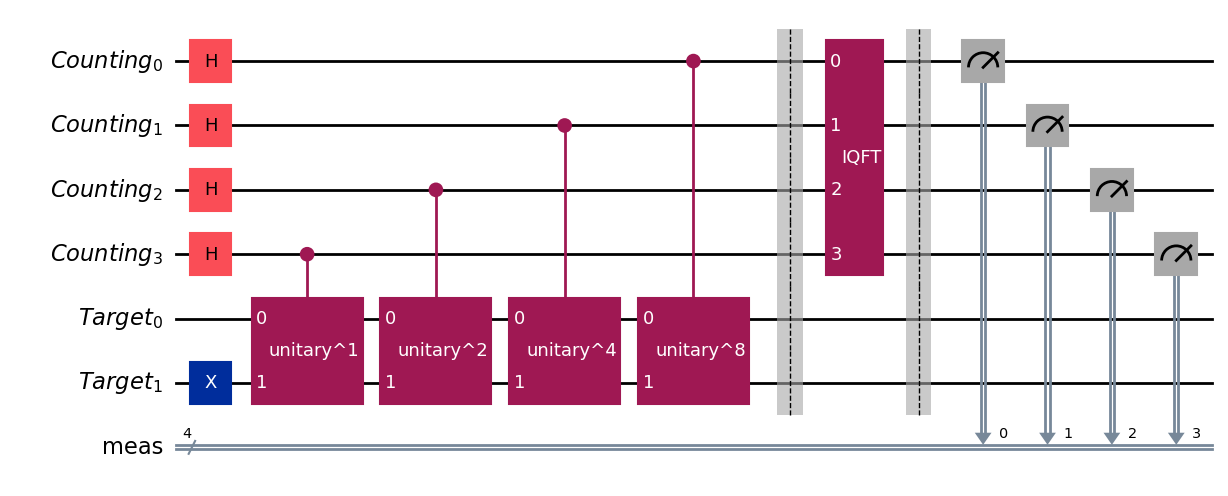

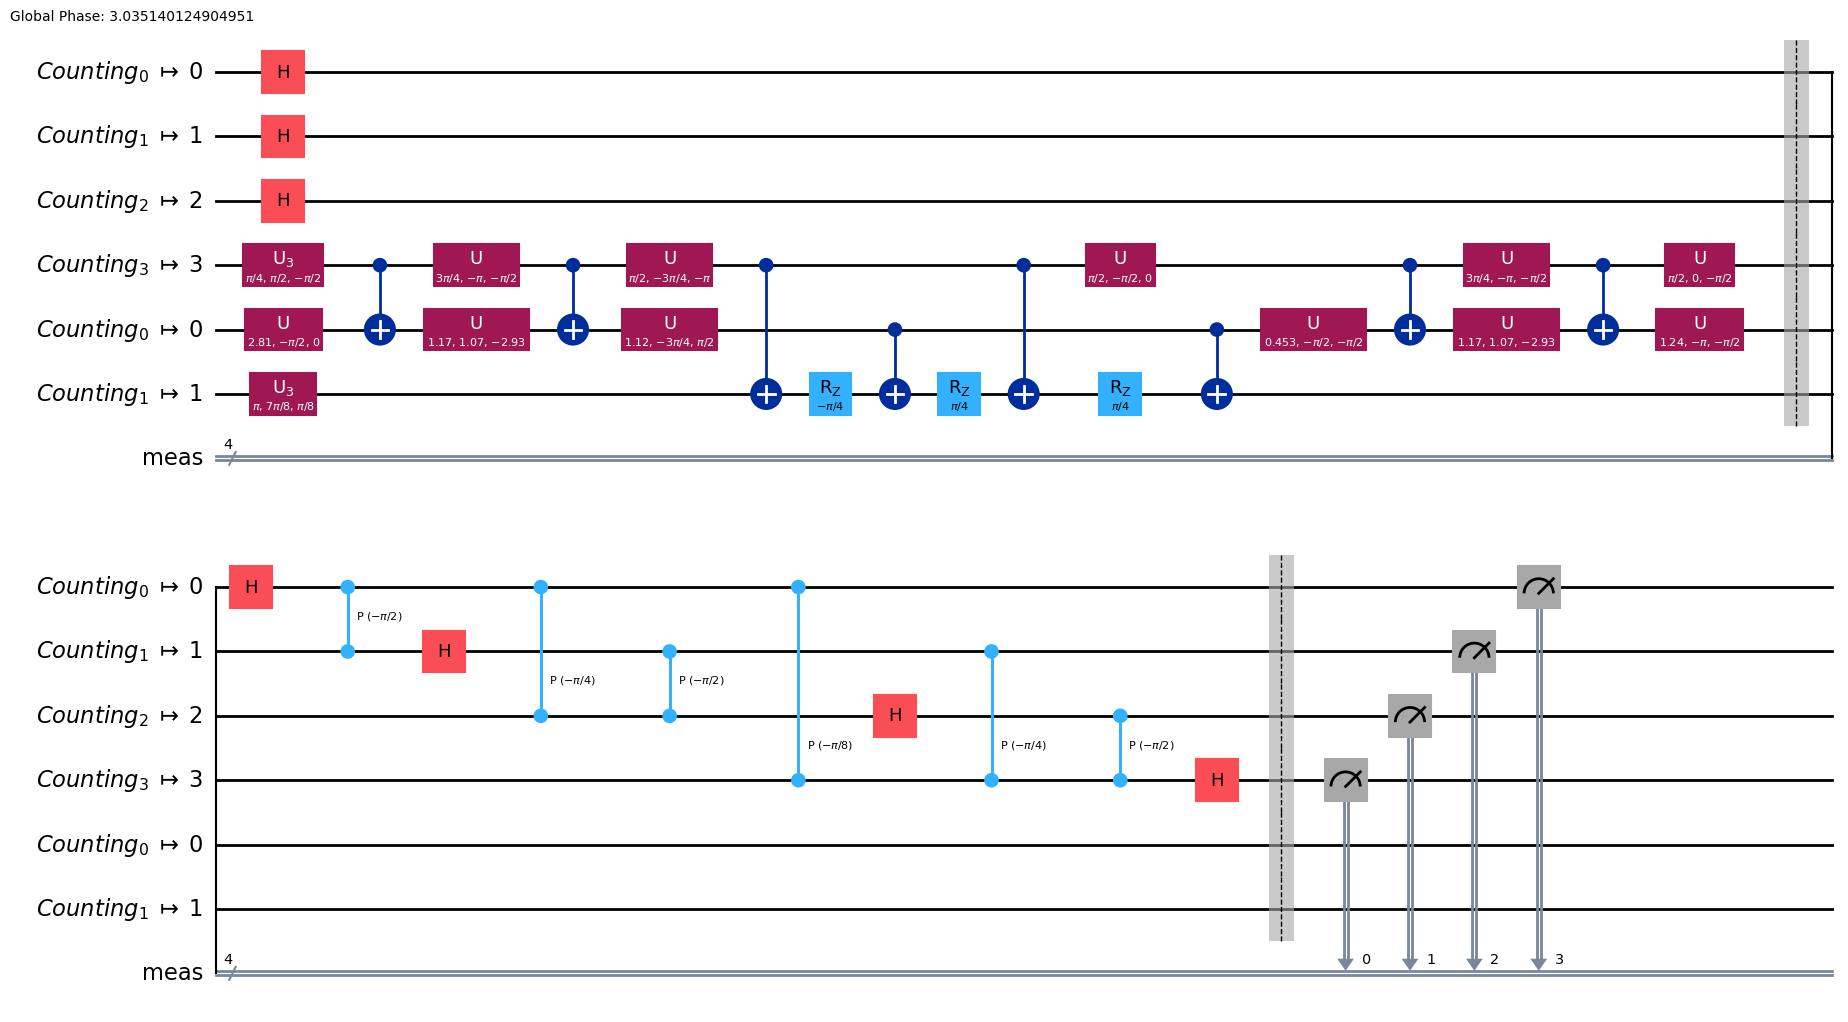

In [6]:
_, qc = shors_algorithm(4, 3)
qc_t = transpile(qc, backend) 
display(qc.draw("mpl"))
display(qc_t.draw("mpl"))

Let's now try to factor some numbers! We'll try to factor $N=15$ using $a=2$.

In [ ]:
# Initial comprobations
N = 15
a = 2

assert 1 < a < N, "The base a must satisfy 1 < a < N"
assert gcd(a, N) == 1, "The base a and N must be coprimes"

Value: 128, Value/2^m: 0.5
Value: 0, Value/2^m: 0.0
Value: 64, Value/2^m: 0.25
Value: 192, Value/2^m: 0.75


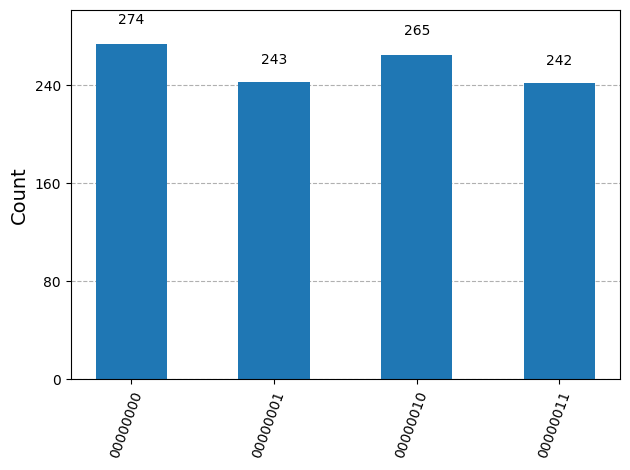

In [ ]:
# Build and run the circuit
m, qc = shors_algorithm(N, a)
qc_t = transpile(qc, backend) 
job = sampler.run([qc_t], shots=1024)
counts = job.result()[0].data.meas.get_counts()

# Get the results
for k in counts:
    c = int(k[::-1], 2)
    print(f"Value: {c}, Value/2^m: {c/2**m}")

# Visualize the distribution
plot_histogram(counts)


We got the values 64 128 and 192 (and 0 but it's trivial), which are clearly multiples of 64. if we divide them by $2^m=256$ we get the fractions $\frac{1}{4}$, $\frac{2}{4}$ and $\frac{3}{4}$, so we found that $r=4$. With that in mind, we can easily calculate the factors of $N=15$.

In [17]:
# Comprobations of r
r = 4

assert r % 2 == 0, "The period r must be even"
assert a**(r/2) != (-1) % N, "The value a**(r/2) % N must not be equal to -1 % N"

In [18]:
# Get the factors
x = int((a**(r/2) + 1) % N)
y = int((a**(r/2) - 1) % N)

p = gcd(x, N)
q = gcd(y, N)

print(50 * "#")
print(f"Factors guessed by Shor's algorithm: {p} and {q}")
print(50 * "#")

##################################################
Factors guessed by Shor's algorithm: 5 and 3
##################################################


The algorithm returned 3 and 5, which are obviously factors of 15. Let's now try to factor $N=21$ using $a=16$.

In [39]:
# Initial comprobations
N = 21
a = 16

assert 1 < a < N, "The base a must satisfy 1 < a < N"
assert gcd(a, N) == 1, "The base a and N must be coprimes"

Value: 0, Value/2^m: 0.0
Value: 341, Value/2^m: 0.3330078125
Value: 682, Value/2^m: 0.666015625
Value: 340, Value/2^m: 0.33203125
Value: 683, Value/2^m: 0.6669921875
Value: 342, Value/2^m: 0.333984375
Value: 681, Value/2^m: 0.6650390625
Value: 684, Value/2^m: 0.66796875


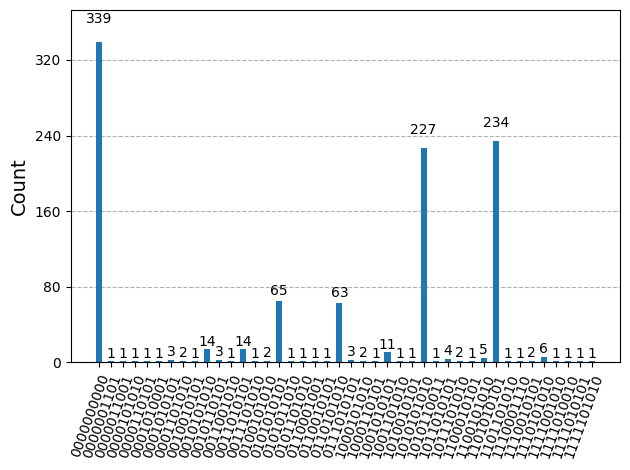

In [40]:
# Build and run the circuit
m, qc = shors_algorithm(N, a)
qc_t = transpile(qc, backend) 
job = sampler.run([qc_t], shots=1024)
counts = job.result()[0].data.meas.get_counts()

# Get the results
for k in counts:
    if counts[k] > 10:
        c = int(k[::-1], 2)
        print(f"Value: {c}, Value/2^m: {c/2**m}")

# Visualize the distribution
plot_histogram(counts)

In this case, the fractions aren't exactly representable with our grid, but we can easily see that we have $341/2^m \approx 1/3$ and $682/2^m \approx 2/3$ so the period is $r=3$. Since $r$ is odd, we must try another value of $a$

In [34]:
# Initial comprobations
N = 21
a = 10

assert 1 < a < N, "The base a must satisfy 1 < a < N"
assert gcd(a, N) == 1, "The base a and N must be coprimes"

Value: 171, Value/2^m: 0.1669921875
Value: 683, Value/2^m: 0.6669921875
Value: 0, Value/2^m: 0.0
Value: 341, Value/2^m: 0.3330078125
Value: 512, Value/2^m: 0.5
Value: 342, Value/2^m: 0.333984375
Value: 853, Value/2^m: 0.8330078125
Value: 682, Value/2^m: 0.666015625
Value: 170, Value/2^m: 0.166015625
Value: 854, Value/2^m: 0.833984375


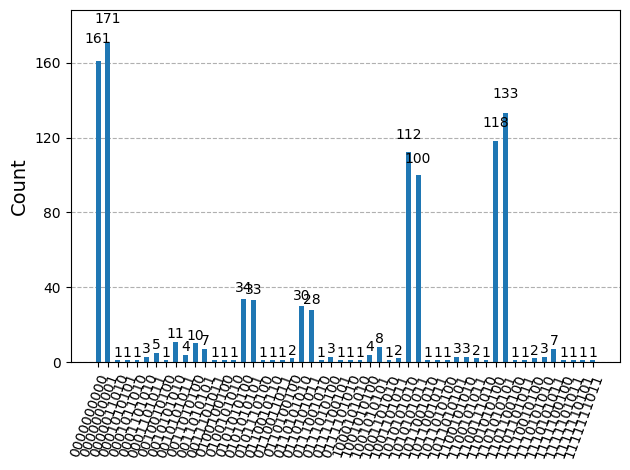

In [38]:
# Build and run the circuit
m, qc = shors_algorithm(N, a)
qc_t = transpile(qc, backend) 
job = sampler.run([qc_t], shots=1024)
counts = job.result()[0].data.meas.get_counts()

# Get the results
for k in counts:
    if counts[k] > 20:
        c = int(k[::-1], 2)
        print(f"Value: {c}, Value/2^m: {c/2**m}")

# Visualize the distribution
plot_histogram(counts)

The fractions now seem to be $\frac{1}{6}, \frac{2}{6}, \frac{3}{6}, \frac{4}{6}$ and $\frac{5}{6}$, so $r=6$.

In [36]:
# Comprobations of r
r = 6

assert r % 2 == 0, "The period r must be even"
assert a**(r/2) != (-1) % N, "The value a**(r/2) % N must not be equal to -1 % N"

In [37]:
# Get the factors
x = int((a**(r/2) + 1) % N)
y = int((a**(r/2) - 1) % N)

p = gcd(x, N)
q = gcd(y, N)

print(50 * "#")
print(f"Factors guessed by Shor's algorithm: {p} and {q}")
print(50 * "#")

##################################################
Factors guessed by Shor's algorithm: 7 and 3
##################################################


Again, the algorithm successfully recovers the non-trivial factors of $N$. Using the estimated period $r$, the classical post-processing step computes the greatest common divisors and obtains the factors $7$ and $3$, confirming that Shor's algorithm has correctly factorized the number.